In [1]:
import pandas as pd

# 1. Ask the robot to read the file (make sure the file name matches yours!)
# We will call our table 'df' (short for DataFrame)
df = pd.read_csv('New York Citi Bike Trip Histories 2015 - 2017.csv')

# 2. Peek at the first 5 rows to see what our clues look like
print(df.head())

   Unnamed: 0  Trip Duration      Start Time       Stop Time  \
0           0            376  10/1/2015 0:16  10/1/2015 0:22   
1           1            739  10/1/2015 0:27  10/1/2015 0:39   
2           2           2714  10/1/2015 0:32  10/1/2015 1:18   
3           3            275  10/1/2015 0:34  10/1/2015 0:39   
4           4            561  10/1/2015 0:40  10/1/2015 0:49   

   Start Station ID Start Station Name  Start Station Latitude  \
0              3212    Christ Hospital               40.734786   
1              3207        Oakland Ave               40.737604   
2              3193       Lincoln Park               40.724605   
3              3199       Newport Pkwy               40.728745   
4              3183     Exchange Place               40.716247   

   Start Station Longitude  End Station ID    End Station Name  \
0               -74.050444            3207         Oakland Ave   
1               -74.052478            3212     Christ Hospital   
2               -74.

## Citi Bike Analysis: Questions 9 and 10

This section analyzes:

1. Whether **Subscribers** and **Customers** ride at different times of day.
2. How **trip distance** (station-to-station proximity) relates to ride frequency.

We will clean key columns, create hourly and distance-based summaries, and visualize both patterns.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Keep a working copy
bike = df.copy()

# Standardize column names for easier coding
bike.columns = (
    bike.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Helper: pick the first matching column from candidates
def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

cols = set(bike.columns)

start_time_col = pick_col(["start_time", "starttime"], cols)
stop_time_col = pick_col(["stop_time", "stoptime"], cols)
user_type_col = pick_col(["user_type", "usertype"], cols)
trip_duration_col = pick_col(["trip_duration_seconds", "trip_duration_(seconds)", "trip_duration", "tripduration"], cols)
year_birth_col = pick_col(["year_of_birth", "birth_year"], cols)

if start_time_col is None or user_type_col is None:
    raise ValueError("Required columns not found for analysis: start_time and/or user_type.")

# Parse date/time columns
bike[start_time_col] = pd.to_datetime(bike[start_time_col], errors="coerce")
if stop_time_col is not None:
    bike[stop_time_col] = pd.to_datetime(bike[stop_time_col], errors="coerce")

# Clean user_type labels and keep major categories
bike[user_type_col] = bike[user_type_col].astype(str).str.strip().str.title()
bike[user_type_col] = bike[user_type_col].replace({"Casual": "Customer"})

# Numeric cleanup where available
if trip_duration_col is not None:
    bike[trip_duration_col] = pd.to_numeric(bike[trip_duration_col], errors="coerce")
if year_birth_col is not None:
    bike[year_birth_col] = pd.to_numeric(bike[year_birth_col], errors="coerce")

# Drop rows missing essential values for time/user analysis
bike = bike.dropna(subset=[start_time_col, user_type_col])

# Optional sanity filter for duration (remove zero/negative/extreme)
if trip_duration_col is not None:
    bike = bike[(bike[trip_duration_col] > 0) & (bike[trip_duration_col] < 24 * 3600)]

# Align to canonical names used in later cells
bike = bike.rename(columns={start_time_col: "start_time", user_type_col: "user_type"})

print("Data cleaned. Rows available:", len(bike))
print("User types:", bike["user_type"].value_counts(dropna=False).to_dict())

Data cleaned. Rows available: 735173
User types: {'Subscriber': 687993, 'Customer': 47180}


## 9) Are subscribers more likely to ride at specific times compared to customers?

We count trips by hour and compare **Subscriber** vs **Customer** riding patterns.

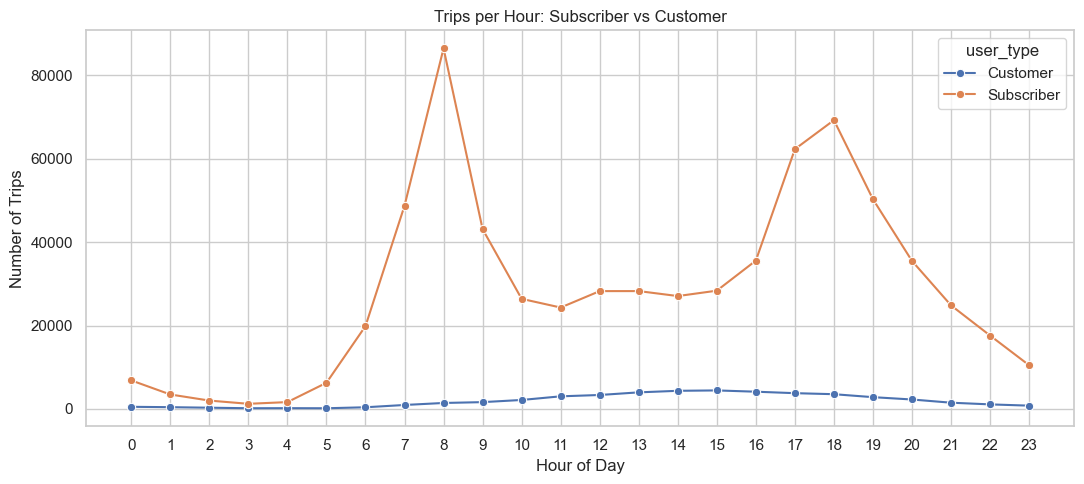

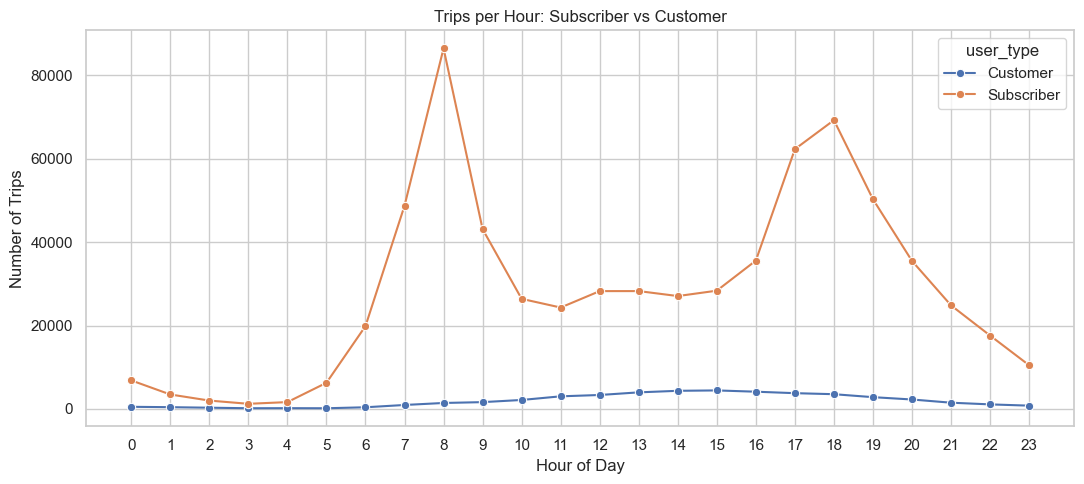

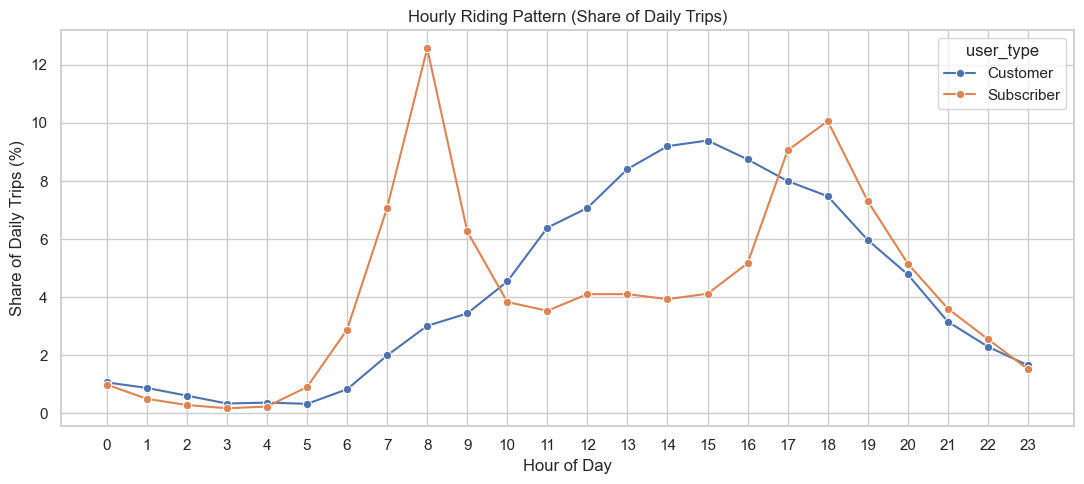

Peak hour summary:
 user_type  hour  trip_count
  Customer    15        4433
Subscriber     8       86460

Interpretation:
If Subscriber peaks are around commute times (morning/evening), subscribers are more schedule-driven.
If Customer trips concentrate in late morning/afternoon, customers are more leisure-oriented.


In [7]:
# Trips per hour by user type
hourly = (
    bike.assign(hour=bike["start_time"].dt.hour)
        .groupby(["hour", "user_type"], as_index=False)
        .size()
        .rename(columns={"size": "trip_count"})
)

hourly = hourly[hourly["user_type"].isin(["Subscriber", "Customer"])]

plt.figure(figsize=(11, 5))
sns.lineplot(data=hourly, x="hour", y="trip_count", hue="user_type", marker="o")
plt.title("Trips per Hour: Subscriber vs Customer")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Also show normalized pattern so shape comparison is easier
hourly_share = hourly.copy()
hourly_share["share_pct"] = (
    hourly_share["trip_count"] /
    hourly_share.groupby("user_type")["trip_count"].transform("sum") * 100
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=hourly_share, x="hour", y="share_pct", hue="user_type", marker="o")
plt.title("Hourly Riding Pattern (Share of Daily Trips)")
plt.xlabel("Hour of Day")
plt.ylabel("Share of Daily Trips (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Short explanation from data
peak_hours = (
    hourly.sort_values("trip_count", ascending=False)
          .groupby("user_type", as_index=False)
          .first()[["user_type", "hour", "trip_count"]]
)

print("Peak hour summary:")
print(peak_hours.to_string(index=False))
print("\nInterpretation:")
print("If Subscriber peaks are around commute times (morning/evening), subscribers are more schedule-driven.")
print("If Customer trips concentrate in late morning/afternoon, customers are more leisure-oriented.")

## 10) Relationship between station proximity and frequency of rides

We estimate station-to-station distance using the Haversine formula on latitude/longitude, bin distances, and count trips per bin.

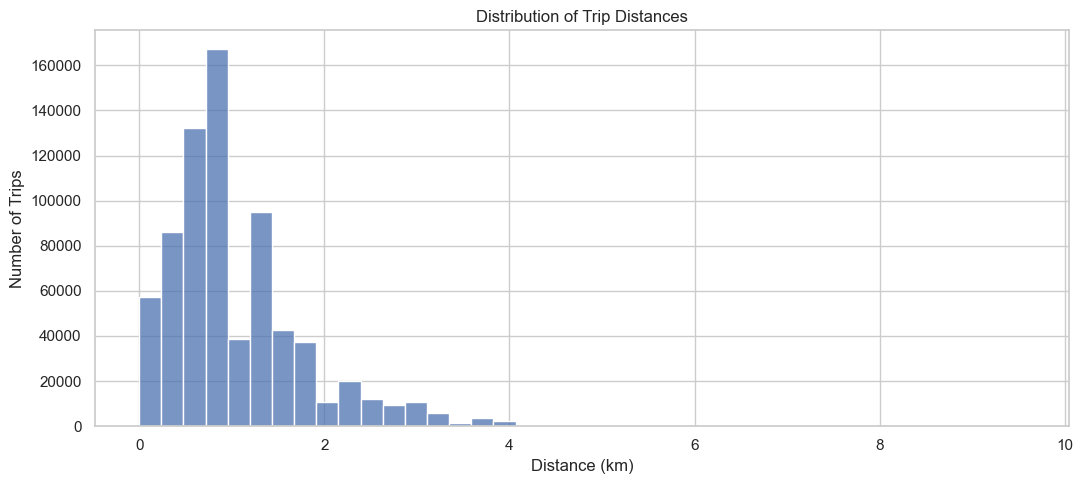

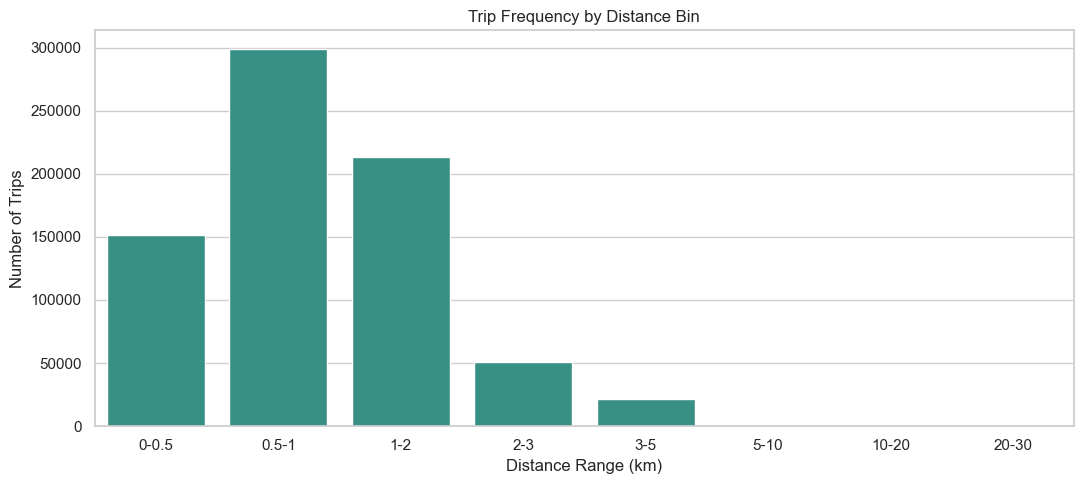

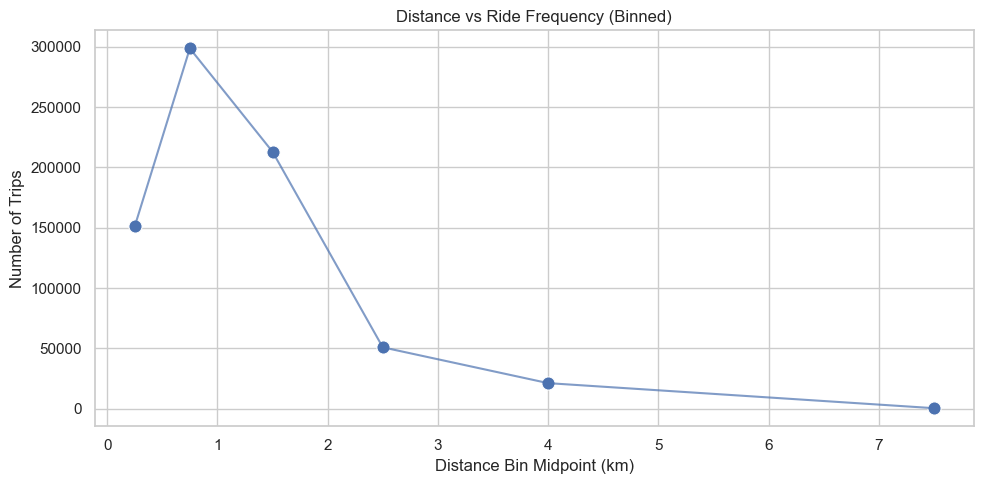

Most frequent distance bin:
distance_bin_km  trip_count
          0.5-1      298618

Interpretation:
If shorter bins dominate, riders mostly travel between nearby stations.
A steady drop in counts as distance increases suggests inverse distance-frequency behavior.


In [3]:
# Required latitude/longitude columns
required_cols = [
    "start_station_latitude", "start_station_longitude",
    "end_station_latitude", "end_station_longitude"
]

missing = [c for c in required_cols if c not in bike.columns]
if missing:
    raise ValueError(f"Missing columns for distance analysis: {missing}")

# Haversine distance in kilometers
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

# Compute trip distance
dist = bike.dropna(subset=required_cols).copy()
dist["distance_km"] = haversine_km(
    dist["start_station_latitude"],
    dist["start_station_longitude"],
    dist["end_station_latitude"],
    dist["end_station_longitude"]
)

# Remove impossible/extreme distances for cleaner visualization
dist = dist[(dist["distance_km"] >= 0) & (dist["distance_km"] <= 30)]

# Distance bins
bins = [0, 0.5, 1, 2, 3, 5, 10, 20, 30]
labels = ["0-0.5", "0.5-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-30"]
dist["distance_bin_km"] = pd.cut(dist["distance_km"], bins=bins, labels=labels, include_lowest=True)

distance_freq = (
    dist.groupby("distance_bin_km", observed=True)
        .size()
        .reset_index(name="trip_count")
)

# Histogram of raw distances
plt.figure(figsize=(11, 5))
sns.histplot(dist["distance_km"], bins=40, kde=False)
plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

# Bar chart: trip frequency by distance bin
plt.figure(figsize=(11, 5))
sns.barplot(data=distance_freq, x="distance_bin_km", y="trip_count", color="#2a9d8f")
plt.title("Trip Frequency by Distance Bin")
plt.xlabel("Distance Range (km)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

# Optional scatter (bin midpoint vs frequency)
midpoints = np.array([0.25, 0.75, 1.5, 2.5, 4.0, 7.5, 15.0, 25.0])
scatter_df = distance_freq.copy()
scatter_df["midpoint_km"] = midpoints[:len(scatter_df)]

plt.figure(figsize=(10, 5))
sns.scatterplot(data=scatter_df, x="midpoint_km", y="trip_count", s=90)
sns.lineplot(data=scatter_df, x="midpoint_km", y="trip_count", alpha=0.7)
plt.title("Distance vs Ride Frequency (Binned)")
plt.xlabel("Distance Bin Midpoint (km)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

# Short explanation from data
top_bin = distance_freq.sort_values("trip_count", ascending=False).head(1)
print("Most frequent distance bin:")
print(top_bin.to_string(index=False))
print("\nInterpretation:")
print("If shorter bins dominate, riders mostly travel between nearby stations.")
print("A steady drop in counts as distance increases suggests inverse distance-frequency behavior.")